In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

#pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

pd.reset_option('display.max_rows')
#pd.reset_option('display.max_columns')

In [4]:
filePath = 'test_data.csv'
df = pd.read_csv(filePath)
df

,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,HS,AS,HST,AST,HC,AC,HF,AF,HY,AY,HR,AR,IWH,IWD,IWA,WHH,WHD,WHA,B365H,B365D,B365A,B365>2.5,B365<2.5,Date,Season,Year,Month,DayOfWeek,TotalGoals,GoalsOver2_5,HomeTeam_mean_FTHG,AwayTeam_mean_FTAG,HomeTeam,AwayTeam,HomeTeam_Arsenal,HomeTeam_Aston Villa,HomeTeam_Birmingham,HomeTeam_Blackburn,HomeTeam_Blackpool,HomeTeam_Bolton,HomeTeam_Bournemouth,HomeTeam_Brentford,HomeTeam_Brighton,HomeTeam_Burnley,HomeTeam_Cardiff,HomeTeam_Charlton,HomeTeam_Chelsea,HomeTeam_Crystal Palace,HomeTeam_Derby,HomeTeam_Everton,HomeTeam_Fulham,HomeTeam_Huddersfield,HomeTeam_Hull,HomeTeam_Leeds,HomeTeam_Leicester,HomeTeam_Liverpool,HomeTeam_Luton,HomeTeam_Man City,HomeTeam_Man United,HomeTeam_Middlesbrough,HomeTeam_Newcastle,HomeTeam_Norwich,HomeTeam_Nott'm Forest,HomeTeam_Portsmouth,HomeTeam_QPR,HomeTeam_Reading,HomeTeam_Sheffield United,HomeTeam_Southampton,HomeTeam_Stoke,HomeTeam_Sunderland,HomeTeam_Swansea,HomeTeam_Tottenham,HomeTeam_Watford,HomeTeam_West Brom,HomeTeam_West Ham,HomeTeam_Wigan,HomeTeam_Wolves,AwayTeam_Arsenal,AwayTeam_Aston Villa,AwayTeam_Birmingham,AwayTeam_Blackburn,AwayTeam_Blackpool,AwayTeam_Bolton,AwayTeam_Bournemouth,AwayTeam_Brentford,AwayTeam_Brighton,AwayTeam_Burnley,AwayTeam_Cardiff,AwayTeam_Charlton,AwayTeam_Chelsea,AwayTeam_Crystal Palace,AwayTeam_Derby,AwayTeam_Everton,AwayTeam_Fulham,AwayTeam_Huddersfield,AwayTeam_Hull,AwayTeam_Leeds,AwayTeam_Leicester,AwayTeam_Liverpool,AwayTeam_Luton,AwayTeam_Man City,AwayTeam_Man United,AwayTeam_Middlesbrough,AwayTeam_Newcastle,AwayTeam_Norwich,AwayTeam_Nott'm Forest,AwayTeam_Portsmouth,AwayTeam_QPR,AwayTeam_Reading,AwayTeam_Sheffield United,AwayTeam_Southampton,AwayTeam_Stoke,AwayTeam_Sunderland,AwayTeam_Swansea,AwayTeam_Tottenham,AwayTeam_Watford,AwayTeam_West Brom,AwayTeam_West Ham,AwayTeam_Wigan,AwayTeam_Wolves,has_ou_odds,HomeRecentGF,HomeRecentGA,HomeRecentPts,AwayRecentGF,AwayRecentGA,AwayRecentPts,B365>2.5_missing,B365<2.5_missing,h2h_home_wins_last5,home_league_position,away_league_position,position_diff,HomePts,AwayPts,HomeGoalDiff,AwayGoalDiff,HomeRecentGoalDiff,AwayRecentGoalDiff,RecentGoalDiff,HomeRecentShotsOnTarget,AwayRecentShotsOnTarget,RecentShotsOnTargetDiff,PosDiff,B365>2.5_implied_prob,B365<2.5_implied_prob,OddsMargin,OU_OddsMargin,OverUnderRatio,Weekend,RefereeAggression,EarlySeason
0,5.0,2.0,H,3.0,0.0,H,P Durkin,10.0,8.0,8.0,6.0,1.0,1.0,9.0,9.0,3.0,2.0,0.0,0.0,1.20,5.00,10.00,1.16,5.50,12.00,1.17,5.50,13.00,1.90,1.91,2002-08-27,2002-03,2002,8,1,7.0,1,2.120907,0.873469,Arsenal,West Brom,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,2.0,0.0,8.0,0.0,1.0,5.0,1,1,0,1,1,0,3,0,3.0,-3.0,2.0,-2.0,3.0,28.0,22.0,6.0,0,0.526316,0.523560,0.090000,0.994764,0.994764,0,0.0,0
1,0.0,1.0,A,0.0,1.0,A,A Wiley,10.0,7.0,5.0,1.0,6.0,9.0,9.0,23.0,1.0,2.0,0.0,0.0,2.30,3.00,2.70,2.50,3.10,2.50,2.40,3.20,2.60,1.90,1.91,2002-08-27,2002-03,2002,8,1,1.0,0,1.337079,1.449749,Charlton,Tottenham,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,2.0,3.0,8.0,2.0,2.0,5.0,1,1,0,3,3,0,0,3,-1.0,1.0,2.0,-2.0,3.0,28.0,22.0,6.0,0,0.526316,0.523560,0.923077,0.994764,0.994764,0,0.0,0
2,1.0,1.0,D,0.0,0.0,D,E Wolstenholme,11.0,5.0,4.0,2.0,7.0,4.0,18.0,12.0,0.0,3.0,1.0,0.0,1.60,3.40,4.60,1.66,3.30,4.50,1.67,3.40,4.50,1.90,1.91,2002-08-28,2002-03,2002,8,2,2.0,0,1.537500,0.836066,Everton,Birmingham,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2.0,2.0,8.0,0.0,2.0,5.0,1,1,0,5,5,0,1,1,0.0,0.0,2.0,-2.0,3.0,28.0,22.0,6.0,0,0.526316,0.523560,0.371111,0.994764,0.994764,0,0.0,0
3,0.0,1.0,A,0.0,0.0,D,M Halsey,20.0,9.0,9.0,4.0,8.0,1.0,13.0,11.0,2.0,0.0,0.0,0.0,1.40,3.90,6.00,1.36,3.75,8.00,1.50,3.40,6.50,1.90,1.9

Home Goals MAE: 0.984933586337761
Home Goals RMSE: 1.2329199950138683
Away Goals MAE: 0.8691334598355472
Away Goals RMSE: 1.0888275120714224


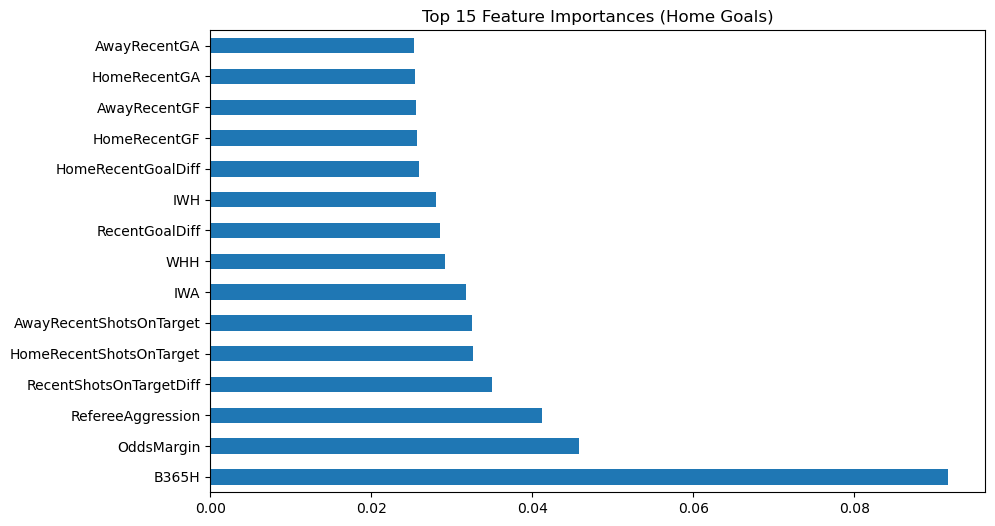

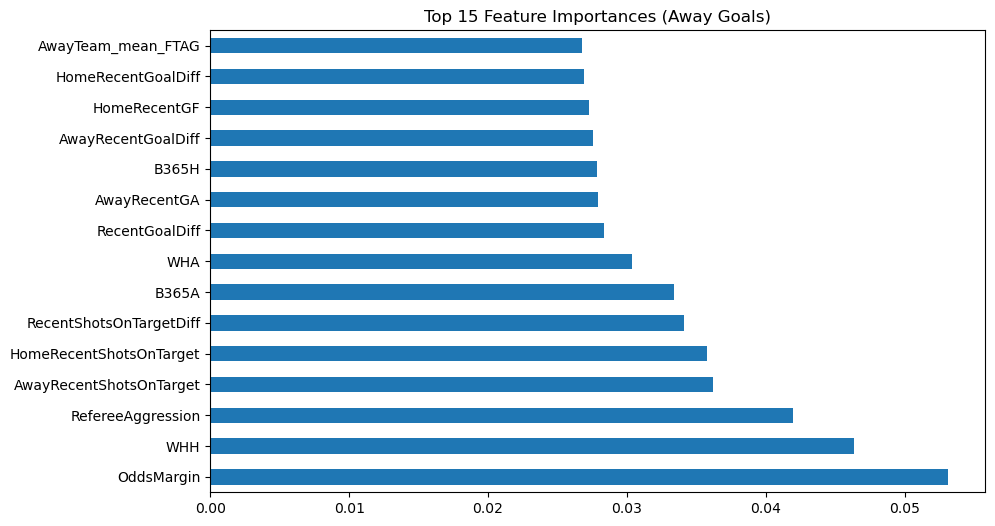

In [5]:
cols_to_drop = [
    'GoalsOver2_5', 'TotalGoals', 'FTHG', 'FTAG',
    'HTHG', 'HTAG',
    'HS', 'AS', 'HST', 'AST',  
    'HC', 'AC',               
    'HF', 'AF',               
    'HY', 'AY',               
    'HR', 'AR',               
    'FTR_H', 'FTR_A', 'FTR_D',
    'HTR_H', 'HTR_A', 'HTR_D',
    'FTR', 'HTR',
    'HomeTeam', 'AwayTeam',
    'Date', 'Referee',
    'Season',
    'HomeGoalDiff', 'AwayGoalDiff',
    'HomePts', 'AwayPts'    
]

X = df.drop(columns=cols_to_drop, errors='ignore')
y = df[['FTHG', 'FTAG']] 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf_home = RandomForestRegressor(n_estimators=100, random_state=42)
rf_home.fit(X_train, y_train['FTHG'])
y_pred_home = rf_home.predict(X_test)
print("Home Goals MAE:", mean_absolute_error(y_test['FTHG'], y_pred_home))
print("Home Goals RMSE:", np.sqrt(mean_squared_error(y_test['FTHG'], y_pred_home)))

rf_away = RandomForestRegressor(n_estimators=100, random_state=42)
rf_away.fit(X_train, y_train['FTAG'])
y_pred_away = rf_away.predict(X_test)
print("Away Goals MAE:", mean_absolute_error(y_test['FTAG'], y_pred_away))
print("Away Goals RMSE:", np.sqrt(mean_squared_error(y_test['FTAG'], y_pred_away)))

feat_importances_home = pd.Series(rf_home.feature_importances_, index=X.columns)
feat_importances_away = pd.Series(rf_away.feature_importances_, index=X.columns)

plt.figure(figsize=(10, 6))
feat_importances_home.nlargest(15).plot(kind='barh')
plt.title('Top 15 Feature Importances (Home Goals)')
plt.show()

plt.figure(figsize=(10, 6))
feat_importances_away.nlargest(15).plot(kind='barh')
plt.title('Top 15 Feature Importances (Away Goals)')
plt.show()